In [17]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle, FancyArrow
import matplotlib.gridspec as gridspec
import pandas as pd
import ast
import numpy as np
import glob
import os

Found 4 background-trail files
any shots? False


C:\Users\micha\AppData\Local\Temp\ipykernel_1624\2728915199.py:198: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('hsv', n_agents)


GIF saved to simulation_visualization.gif


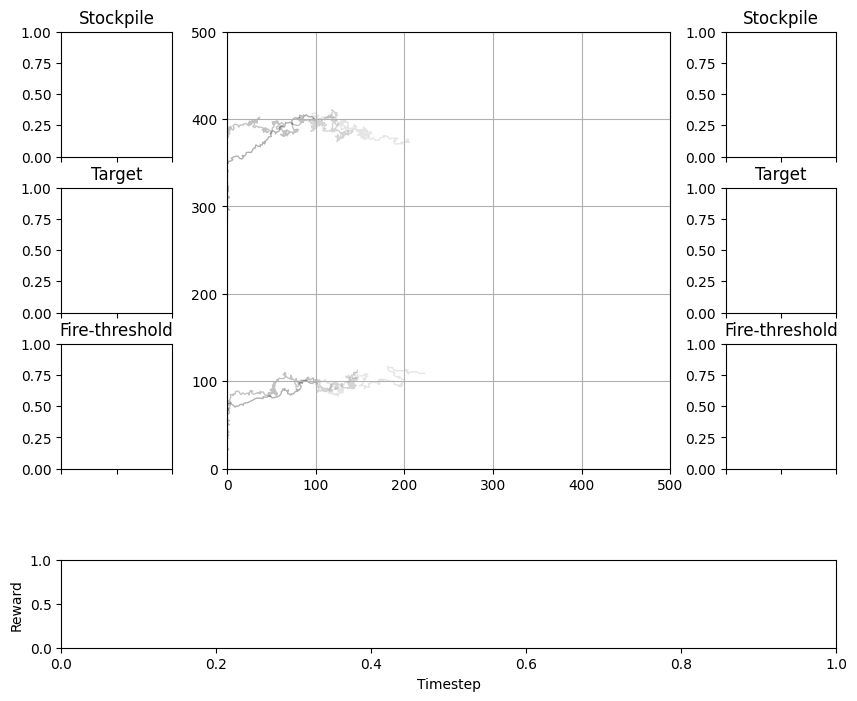

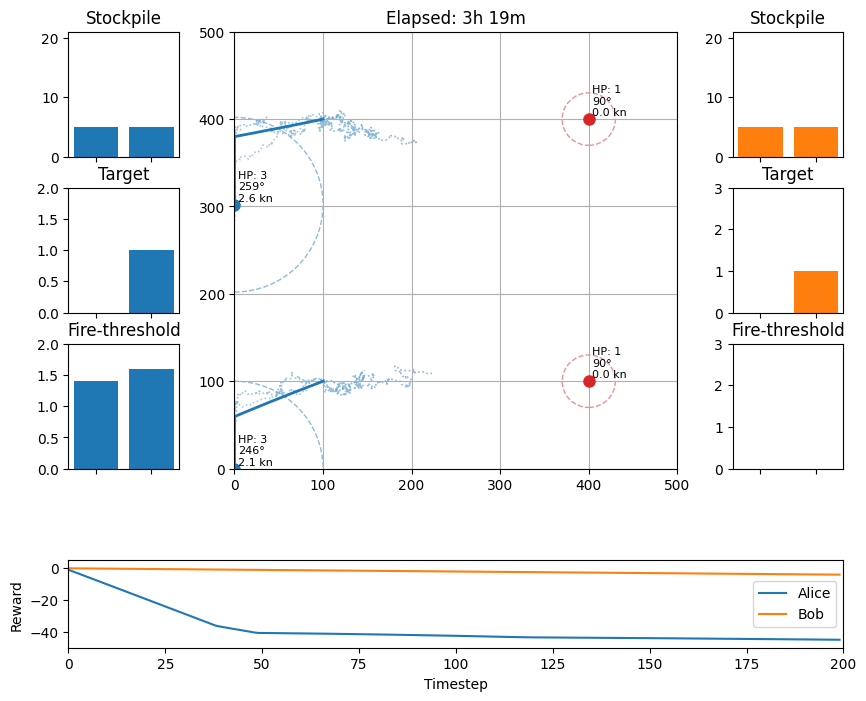

In [ ]:
def course_from_north_deg(rad):
    """Convert course (mathematical radians, 0=east CCW) to bearing degrees where 0°=north, CW positive."""
    deg = np.degrees(rad)
    bearing = (90 - deg) % 360
    return bearing

def meter_per_min_to_knots(m_per_min):
    return m_per_min / 1852 * 60

def interpolate_color(start_color, end_color, factor):
    return tuple(start + (end - start) * factor for start, end in zip(start_color, end_color))

grey_color = (0.5, 0.5, 0.5, 1.0)

engagement_lines = []
engagement_texts = []

def make_canvas(grid_size=500):
    fig = plt.figure(figsize=(10, 8))
    outer = gridspec.GridSpec(
        2, 3, width_ratios=[1, 4, 1], height_ratios=[5, 1],
        hspace=0.35, wspace=0.25)

    map_ax = fig.add_subplot(outer[0, 1])
    map_ax.set_xlim(0, grid_size);  map_ax.set_ylim(0, grid_size);  map_ax.grid(True)

    rew_ax = fig.add_subplot(outer[1, :])
    rew_ax.set_ylabel("Reward");  rew_ax.set_xlabel("Timestep")

    side_spec_L = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[0, 0], hspace=0.25)
    side_spec_R = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=outer[0, 2], hspace=0.25)

    stock_L  = fig.add_subplot(side_spec_L[0]);  stock_L.set_title("Stockpile")
    target_L = fig.add_subplot(side_spec_L[1]);  target_L.set_title("Target")
    thresh_L = fig.add_subplot(side_spec_L[2]);  thresh_L.set_title("Fire-threshold")

    stock_R  = fig.add_subplot(side_spec_R[0]);  stock_R.set_title("Stockpile")
    target_R = fig.add_subplot(side_spec_R[1]);  target_R.set_title("Target")
    thresh_R = fig.add_subplot(side_spec_R[2]);  thresh_R.set_title("Fire-threshold")

    for ax in [stock_L, target_L, thresh_L, stock_R, target_R, thresh_R]:
        ax.tick_params(labelleft=True, labelbottom=False)

    return dict(fig=fig, map_ax=map_ax, rew_ax=rew_ax,
                stock_L=stock_L, target_L=target_L, thresh_L=thresh_L,
                stock_R=stock_R, target_R=target_R, thresh_R=thresh_R)

def visualize_simulation_as_gif(file_path, grid_size=100, total_timesteps=200,
    gif_path="simulation_visualization.gif"):
    
    trail_files = sorted(
        glob.glob(os.path.join(os.path.dirname(file_path),
                                "episode_trail_ep*.npy"))
    )
    trail_files = trail_files[-10:]
    print(f"Found {len(trail_files)} background-trail files")

    df = pd.read_csv(file_path)
    axs = make_canvas(grid_size)
    map_ax = axs["map_ax"];  rew_ax = axs["rew_ax"]


    for rank, tf in enumerate(trail_files):
        trail = np.load(tf)
        alpha = 0.1 + 0.07 * rank
        for agent_id in range(trail.shape[1]):
            xs = trail[:, agent_id, 0]
            ys = trail[:, agent_id, 1]
            map_ax.plot(xs, ys, lw=1.0, alpha=alpha,
                        color='k', zorder=0)
            
    df = pd.read_csv(file_path)

    for col in ["actions", "rewards", "next_state", "fire_data"]:
        df[col] = df[col].apply(ast.literal_eval)
    if isinstance(df["state"].iloc[0], str):
        df["state"] = df["state"].apply(ast.literal_eval)

    example_state = df["state"].iloc[0]
    if len(example_state) % 7 == 0:
        agent_dim, use_dxdy, range_idx, miss_idx = 7, False, 4, 6
    elif len(example_state) % 5 == 0:
        agent_dim, use_dxdy, range_idx, miss_idx = 5, True, 2, 4
    else:
        raise ValueError("Unexpected state length")

    n_agents = len(example_state) // agent_dim
    team_size = n_agents // 2
    team_col = ['tab:blue' if i < team_size else 'tab:red'
            for i in range(n_agents)]
    
    def parse_state(state):
        """Return per-agent dict with position, course, speed, range, missiles, hp."""
        out = []
        for i in range(n_agents):
            base = i * agent_dim
            x, y = state[base], state[base + 1]
            rng = state[base + range_idx]
            missiles = state[base + miss_idx]
            if use_dxdy:
                sp, crs = 0., 0.
            else:
                sp, crs = state[base + 2], state[base + 3]
            hp = state[base + (3 if use_dxdy else 5)]
            out.append(dict(x=x, y=y, rng=rng, sp=sp,
                            crs=crs, missiles=missiles, hp=hp))
        return out

    T = min(total_timesteps, len(df))
    positions, speeds, courses, ranges, missiles_left, hps = [], [], [], [], [], []
    #positions      = np.zeros((T, n_agents, 2))
    #speeds         = np.zeros((T, n_agents))
    #courses        = np.zeros((T, n_agents))
    #ranges         = np.zeros((T, n_agents))
    #missiles_left  = [np.zeros((T, n_agents))]
    fleet_reward   = np.zeros((T, 2))
    firing_param   = np.zeros((T, n_agents))   #  ←  **new**
    chosen_tgt     = np.zeros((T, n_agents), dtype=int)
    firing_thr    = np.zeros((T, 2))

    prev_pos = None
    for t, row in enumerate(df.itertuples()):
        if t >= T:
            break
        st  = parse_state(row.state)
        act = np.array(row.actions).reshape(n_agents, 3)
        
        if t == 0:
            firing_param = np.zeros((T, n_agents))
        firing_param[t] = act[:, 2]

        # kinematics for dx/dy mode
        if use_dxdy:
            if prev_pos is None:
                sp = np.zeros(n_agents);  cr = np.zeros(n_agents)
            else:
                delta = np.array([(s["x"], s["y"]) for s in st]) - prev_pos
                sp = np.linalg.norm(delta, axis=1)
                cr = np.arctan2(delta[:, 1], delta[:, 0])
        else:
            sp = np.array([s["sp"] for s in st])
            cr = np.array([s["crs"] for s in st])

        prev_pos = np.array([(s["x"], s["y"]) for s in st])

        hps.append([s["hp"] for s in st])
        positions.append(prev_pos.copy())
        speeds.append(sp);   courses.append(cr)
        ranges.append([s["rng"] for s in st])
        missiles_left.append([s["missiles"] for s in st])

        # fleet reward
        fleet_reward[t] = [
            sum(row.rewards[:team_size]),
            sum(row.rewards[team_size:])
            ]

        firing_thr[t, 0] = act[:team_size, 2].mean()
        firing_thr[t, 1] = act[team_size:, 2].mean()

        pos_arr = prev_pos
        tgt = []
        for i in range(n_agents):
            enemies = range(team_size, n_agents) if i < team_size else range(0, team_size)
            dists = np.linalg.norm(pos_arr[i] - pos_arr[list(enemies)], axis=1)
            tgt.append(list(enemies)[int(np.argmin(dists))])
        chosen_tgt[t] = tgt

    # trim to requested timesteps
    positions = positions[:T] 
    speeds = speeds[:T] 
    courses = courses[:T]
    ranges = ranges[:T]
    missiles_left = np.array(missiles_left[:T])
    stock_max = missiles_left.sum(axis=1).max()
    fleet_reward = fleet_reward[:T]
    firing_thr = firing_thr[:T]
    chosen_tgt = chosen_tgt[:T]
    shots_frames = df["fire_data"].tolist()[:T]
    print("any shots?", any(len(x) for x in shots_frames))
    hps = np.array(hps[:T])
    positions = np.asarray(positions[:T])
    
    axs = make_canvas(grid_size)
    map_ax = axs["map_ax"];  rew_ax = axs["rew_ax"]

    cmap = plt.cm.get_cmap('hsv', n_agents)
    colors = [cmap(i) for i in range(n_agents)]

    # ships & range circles
    scatters = [map_ax.plot([], [], "o",
                        color=team_col[i],
                        markersize=8)[0]
                        for i in range(n_agents)]
    circles  = [Circle((0, 0), 0,
                        fill=False, ls='--',
                        color=team_col[i],
                        alpha=.5)
                        for i in range(n_agents)]
    hp_texts = [
        map_ax.text(0, 0, '', color='black', fontsize=8)
        for _ in range(n_agents)
        ]
    for c in circles: map_ax.add_patch(c)

    # arrows
    arrows = []

    # fleet-side time-series lines
    x_A = np.arange(team_size)          
    x_B = np.arange(team_size)

    stock_L_bars  = axs["stock_L"].bar(x_A, np.zeros(team_size),
                                        color="tab:blue")
    target_L_bars = axs["target_L"].bar(x_A, np.zeros(team_size),
                                        color="tab:blue")
    thres_L_bars  = axs["thresh_L"].bar(x_A, np.zeros(team_size),
                                        color="tab:blue")
    stock_R_bars  = axs["stock_R"].bar(x_B, np.zeros(team_size),
                                        color="tab:orange")
    target_R_bars = axs["target_R"].bar(x_B, np.zeros(team_size),
                                        color="tab:orange")
    thres_R_bars  = axs["thresh_R"].bar(x_B, np.zeros(team_size),
                                        color="tab:orange")

    rew_L_line, = rew_ax.plot([], [], color="tab:blue", label="Alice")
    rew_R_line, = rew_ax.plot([], [], color="tab:orange", label="Bob")
    rew_ax.legend()

# basic axis
    for name in ["stock_L", "stock_R"]:
        ax = axs[name]
        ax.set_xlim(-0.5, team_size-0.5)       

        ax.set_ylim(0, stock_max + 1)
        
    for name in ["target_L","thresh_L"]:
        ax = axs[name]
        ax.set_xlim(-0.5, team_size-0.5)    

        ax.set_ylim(0, 2)
        
    for name in ["target_R","thresh_R"]:
        ax = axs[name]
        ax.set_xlim(-0.5, team_size-0.5)  

        ax.set_ylim(0, 3)

    
    trail_artists = []

    blue   = np.array([ 31/255, 119/255, 180/255])
    red    = np.array([214/255,  39/255,  40/255])
    white  = np.ones(3)

    for rank, tf in enumerate(trail_files):
        trail   = np.load(tf)
        fade    = 0.15 + 0.07*rank
        for agent_id in range(trail.shape[1]):
            base = blue if agent_id < team_size else red
            col  = base*(1-fade) + white*fade
            ln,  = map_ax.plot(
                trail[:, agent_id, 0],
                trail[:, agent_id, 1],
                ls=':',
                lw=1.2,
                color=col,
                alpha=0.6,
                zorder=1
            )   
            trail_artists.append(ln)
    
    live_trails = []
    for i in range(n_agents):
        base_col = blue if i < team_size else red
        ln, = map_ax.plot([], [], lw=2, color=base_col, zorder=2)
        live_trails.append(ln)
        
    # animation frame update
    def update(frame):
        for i in range(n_agents):
            x, y = positions[frame][i]
            hp = hps[frame, i]
            if hp <= 0:
                scatters[i].set_marker("x")
                scatters[i].set_color(grey_color)
                circles[i].set_visible(False)
            else:
                scatters[i].set_marker("o")
                scatters[i].set_color(team_col[i])
                circles[i].set_visible(True)
                circles[i].center = (x, y)
                circles[i].radius = ranges[frame][i]

            scatters[i].set_data([x], [y])

        # heading arrows
        for a in arrows: 
            a.remove()
        arrows.clear()
        for i in range(n_agents):
            dx = speeds[frame][i] * np.cos(courses[frame][i]) * 3
            dy = speeds[frame][i] * np.sin(courses[frame][i]) * 3
            arr = FancyArrow(positions[frame][i][0], positions[frame][i][1],
                            dx, dy, width=0.1,
                            color=team_col[i],      # ← use team_col
                            alpha=0.6)
            map_ax.add_patch(arr)
            arrows.append(arr)

        # fade existing shot
        for item in engagement_lines:
            item["age"] += 1
            factor = min(1.0, item["age"] / 10)
            new_col = interpolate_color(item["start_color"], grey_color, factor)
            alpha   = max(0.3, 0.8 - 0.05 * item["age"])
            item["line"].set_color(new_col);   item["line"].set_alpha(alpha)

        for item in engagement_texts:
            item["age"] += 1
            factor = min(1.0, item["age"] / 10)
            new_col = interpolate_color(item["start_color"], grey_color, factor)
            alpha   = max(0.3, 1.0 - 0.07 * item["age"])
            item["text"].set_color(new_col);   item["text"].set_alpha(alpha)

        # remove those that are completely faded
        engagement_lines[:] = [itm for itm in engagement_lines if itm["age"] < 15]
        engagement_texts[:] = [itm for itm in engagement_texts if itm["age"] < 15]

        # add fresh shots this timestep
        for shooter, target, missiles in shots_frames[frame]:
            shooter   = int(shooter);  target = int(target);  missiles = int(missiles)
            start_pos = positions[frame][shooter]
            end_pos   = positions[frame][target]

            col = colors[shooter]

            ln, = map_ax.plot([start_pos[0], end_pos[0]],
                        [start_pos[1], end_pos[1]],
                        ls='-', lw=2, color=col, alpha=0.8)
            engagement_lines.append(dict(line=ln, start_color=col, age=0))

            # missile-count text
            tx = start_pos[0] + (end_pos[0] - start_pos[0]) * 0.33
            ty = start_pos[1] + (end_pos[1] - start_pos[1]) * 0.33
            txt = map_ax.text(tx, ty, f"{missiles}",
                        ha='center', va='center',
                        fontsize=9, fontweight='bold', color=col)
            engagement_texts.append(dict(text=txt, start_color=col, age=0))

        
        for i, txt in enumerate(hp_texts):
            x, y   = positions[frame][i]
            hp     = hps[frame, i]
            sp_kn  = meter_per_min_to_knots(speeds[frame][i] * 1852 / 60)
            crsdeg = course_from_north_deg(courses[frame][i])
            if hp <= 0:
                txt.set_text("") 
            else:
                txt.set_position((x + 4, y + 4))
                txt.set_text(f"HP: {hp:.0f}\n{crsdeg:.0f}°\n{sp_kn:.1f} kn")


        
        #  missiles-stockpile
        for k, bar in enumerate(stock_L_bars):
            bar.set_height(missiles_left[frame, k])
        for k, bar in enumerate(stock_R_bars):
            bar.set_height(missiles_left[frame, team_size + k])

        # iring-threshold
        for k, bar in enumerate(target_L_bars):
            bar.set_height(chosen_tgt[frame, k] - team_size)
        for k, bar in enumerate(target_R_bars):
            bar.set_height(chosen_tgt[frame, team_size + k])
        for k, bar in enumerate(thres_L_bars):
            bar.set_height(firing_param[frame, k])
        for k, bar in enumerate(thres_R_bars):
            bar.set_height(firing_param[frame, team_size + k])

        # reward plot
        cum_A = np.cumsum(fleet_reward[:frame+1, 0])
        cum_B = np.cumsum(fleet_reward[:frame+1, 1])

        rew_L_line.set_data(range(frame+1), cum_A)
        rew_R_line.set_data(range(frame+1), cum_B)

        axs["rew_ax"].set_xlim(0, T)
        axs["rew_ax"].set_ylim(min(cum_A.min(), cum_B.min()) - 5,
                            max(cum_A.max(), cum_B.max()) + 5)
        
        map_ax.set_title(f"Elapsed: {frame//60}h {frame%60}m")
        
        for i, ln in enumerate(live_trails):
            ln.set_data(positions[:frame+1, i, 0],
                        positions[:frame+1, i, 1])

        for ax in [axs["thresh_L"], axs["thresh_R"],
                axs["stock_L"],  axs["stock_R"],
                axs["target_L"], axs["target_R"]]:
            ax.set_xlim(-0.5, team_size-0.5)

        return ( trail_artists +
            live_trails + 
            scatters + circles + arrows +
            list(stock_L_bars) + list(stock_R_bars) +
            list(target_L_bars) + list(target_R_bars) +
            list(thres_L_bars)  + list(thres_R_bars) +
            [rew_L_line, rew_R_line] +
            [it["line"] for it in engagement_lines] +
            [it["text"] for it in engagement_texts] )

    # animate and save
    ani = FuncAnimation(axs["fig"], update, frames=T, interval=200, blit=True)
    ani.save(gif_path, writer=PillowWriter(fps=5))
    print(f"GIF saved to {gif_path}")

visualize_simulation_as_gif(
    file_path="episode_data_multi.csv",
    grid_size=500,
    total_timesteps=200,
    gif_path="simulation_visualization.gif")